In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from itertools import product
from typing import Callable, Dict, Optional
from util.data_client.fmp import getFMPData
from util.data_client.dataPullHelpers import normalize_df_for_parquet


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

from dotenv import load_dotenv
load_dotenv()

# Get index data

In [2]:
tickers = ['SPY', 'QQQ', 'IWM', 'RSP']
price_endpoint = "historical-price-eod/dividend-adjusted"
price_data = {}

for tk in tickers:
    price_data[tk] = getFMPData(
        endpoint=price_endpoint,
        symbol=tk.upper(),
        from_="2024-01-01",
        to=date.today().strftime("%Y-%m-%d"),
    )

price_data.keys()

dict_keys(['SPY', 'QQQ', 'IWM', 'RSP'])

In [3]:
dfs = []
for tk, _data in price_data.items():
    _df = pd.DataFrame(_data)
    _df = normalize_df_for_parquet(
        _df,
        datetime_success_ratio=0.9,
        numeric_success_ratio=0.9,
        treat_huge_int_as_string=False
    )
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(['symbol', 'date'], ignore_index=True)
df.shape

(2436, 7)

In [4]:
df

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume
0,IWM,2024-01-02,194.54,196.71,193.61,194.66,44341503
1,IWM,2024-01-03,192.59,192.86,189.06,189.47,57532502
2,IWM,2024-01-04,189.33,190.73,188.97,189.10,43114200
3,IWM,2024-01-05,187.99,190.70,187.60,188.54,40964947
4,IWM,2024-01-08,188.58,192.17,187.58,191.94,31545400
...,...,...,...,...,...,...,...
2431,SPY,2026-06-01,755.36,760.28,754.69,758.54,43634933
2432,SPY,2026-06-02,757.03,760.40,756.75,759.57,31581900
2433,SPY,2026-06-03,758.15,758.80,753.57,754.24,51402518
2434,SPY,2026-06-04,752.10,758.31,751.47,757.09,49923036


In [5]:
df.dtypes

symbol      string[python]
date        datetime64[ns]
adjOpen            float64
adjHigh            float64
adjLow             float64
adjClose           float64
volume               int64
dtype: object

# A1. Return Metrics

## Metric 1 — Rolling Return

In [6]:
import importlib
import util.features.core as f_core
import util.features.families.returns as f_return
import util.features.families.price as f_price
import util.features.families.trend as f_trend
import util.features.families.drawdown as f_dd
import util.features.transforms as trsfm

importlib.reload(f_core)
importlib.reload(f_return)
importlib.reload(f_price)
importlib.reload(f_trend)
importlib.reload(f_dd)
importlib.reload(trsfm)

FeatureBuilder = f_core.FeatureBuilder
RETURN_FAMILY = f_return.RETURN_FAMILY
RAWPRICE_FAMILY = f_price.RAWPRICE_FAMILY
TREND_FAMILY = f_trend.TREND_FAMILY
MDD_FAMILY = f_dd.MDD_FAMILY

In [7]:
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

builder = FeatureBuilder(
    df,
    date_col="date",
    sym_col="symbol",
)

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


def get_features(
    builder: FeatureBuilder,
    family: dict,
    template: str,
    params_lst: list[dict] = [],
    transform_fn: Optional[Callable] = None,
    transform_params: Optional[dict] = None,
) -> dict:

    specs = []

    for params in params_lst:
        base = family[template](**params)
        if transform_fn is None:
            specs += base
        else:
            if transform_params is None:
                transform_params = {}
            specs += transform_fn(base, **transform_params)

    features = builder.build_published(specs)
    return features


def get_feature_df(
    source_df: pd.DataFrame,
    feature_dict: dict,
    symbol_col: str = "symbol",
    date_col: str = "date",
) -> pd.DataFrame:

    feature_df = pd.DataFrame(feature_dict, index=source_df.index)
    feature_df = pd.concat(
        [source_df[[symbol_col, date_col]], feature_df],
        axis=1,
    )
    return feature_df


def get_wide_view(
    feature_df: pd.DataFrame,
    feature_col: str,
    symbol_col: str = "symbol",
    date_col: str = "date",
    window: Optional[int] = None,
) -> pd.DataFrame:

    if window is None:
        window = min(252, feature_df.shape[0])

    df = feature_df.groupby(symbol_col).tail(window)
    df = df[[symbol_col, date_col, feature_col]]
    v = pd.pivot(
        df,
        columns=symbol_col,
        index=date_col,
        values=feature_col
    )
    v = v.sort_index()
    return v


def get_asset_panel(
    feature_df: pd.DataFrame,
    symbol_col: str = "symbol",
    column_names: Optional[list[str]] = None,
) -> pd.DataFrame:

    v = feature_df.groupby(symbol_col).tail(1).set_index(symbol_col)
    v = v.iloc[:, 1:]
    if column_names is not None:
        v.columns = column_names
    return v


def trend_plot(
    wide_df: pd.DataFrame,
    title: str,
    ylabel: str,
    figsize: tuple[float] = (12.0, 5.5),
    symbols: Optional[list[str]] = None,
    is_percentage: bool = True,
) -> None:

    if symbols is not None:
        df = wide_df[symbols].copy()
    else:
        df = wide_df.copy()

    fig, ax = plt.subplots(figsize=figsize, dpi=130)

    for col in df.columns:
        ax.plot(df.index, df[col], label=col, linewidth=2)

    ax.axhline(0, linewidth=1, alpha=0.7)

    ax.set_title(title, fontsize=16, weight="bold", pad=14)
    ax.set_ylabel(ylabel)
    if is_percentage:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, ncol=len(df.columns), loc="upper left")

    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


def panel_plot(
    panel_df: pd.DataFrame,
    title: str,
    figsize: tuple[float] = (7, 3.5),
    features: Optional[list[str]] = None,
    is_percentage: bool = True,
    cmap: str = "RdYlGn",
) -> None:

    if features is not None:
        df = panel_df[features].copy()
    else:
        df = panel_df.copy()

    if is_percentage:
        fmt = ".1%"
        cbar_kws = {"format": mtick.PercentFormatter(1.0)}
    else:
        fmt = ".2f"
        cbar_kws = None

    fig, ax = plt.subplots(figsize=figsize, dpi=130)

    sns.heatmap(
        df,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        center=0,
        linewidths=0.5,
        cbar_kws=cbar_kws,
        ax=ax
    )

    ax.set_title(title, fontsize=14, weight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

In [9]:
list(RETURN_FAMILY.keys())

['RETURN',
 'ANNUALIZED_SIMPLE_RETURN',
 'MOVING_AVERAGE_RETURN',
 'MOVING_VOLATILITY_RETURN',
 'RETURN_ZSCORE',
 'RETURN_RATIO',
 'REALIZED_VOLATILITY']

In [10]:
return_features = {}

price_cols = ["adjClose"]
lookbacks = [5, 10, 20, 60, 126]
windows = [60]

params_list_1 = [
    {"price_col": p, "lookback": lb}
    for p in price_cols for lb in lookbacks
]

params_list_2 = [
    {"price_col": p, "lookback": lb, "window": w}
    for p in price_cols for lb in lookbacks for w in windows
]

return_features["raw"] = get_features(
    builder=builder,
    family=RETURN_FAMILY,
    template="RETURN",
    params_lst=params_list_1
)

# return_features["zscore"] = get_features(
#     builder=builder,
#     family=RETURN_FAMILY,
#     template="RETURN_ZSCORE",
#     params_lst=params_list_2
# )

return_features["zscore"] = get_features(
    builder=builder,
    family=RETURN_FAMILY,
    template="RETURN",
    params_lst=params_list_1,
    transform_fn=trsfm.add_ts_zscore,
    transform_params={"z_window": 60, "include_base": False}
)

In [11]:
raw_return_df = get_feature_df(df, return_features["raw"])
raw_return_wide = get_wide_view(raw_return_df, "px__ret__logret__lb10__raw")
raw_return_wide

symbol,IWM,QQQ,RSP,SPY
date,,,,
2025-06-05,0.025828,0.022637,0.008936,0.017324
2025-06-06,0.041938,0.030515,0.020698,0.027157
2025-06-09,0.051922,0.041264,0.024826,0.034909
2025-06-10,0.032275,0.024621,0.011386,0.019989
2025-06-11,0.038734,0.025674,0.017062,0.022934
...,...,...,...,...
2026-06-01,0.040176,0.046589,0.037251,0.025868
2026-06-02,0.055297,0.055495,0.035078,0.027928
2026-06-03,0.052342,0.059060,0.037145,0.027570


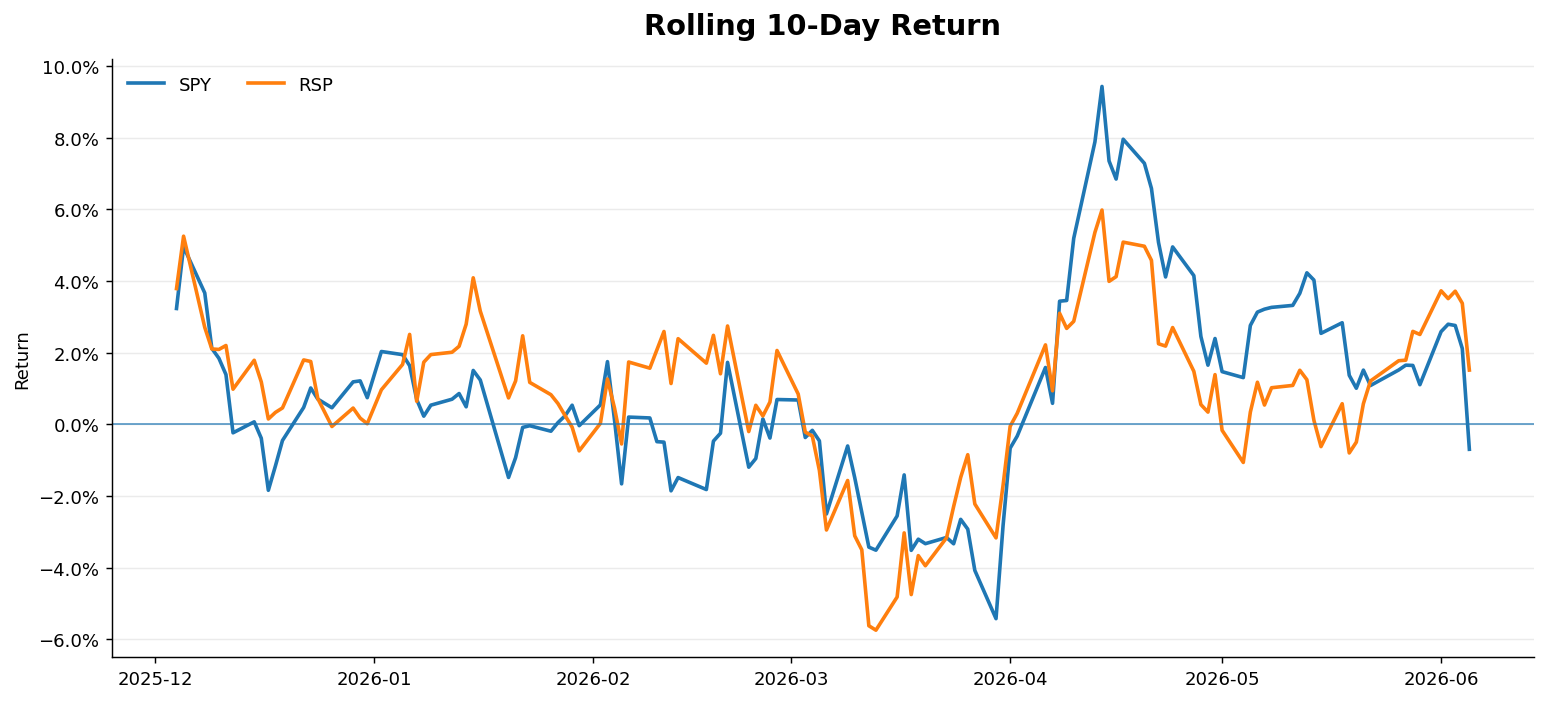

In [12]:
trend_plot(
    raw_return_wide.tail(126),
    title="Rolling 10-Day Return",
    ylabel="Return",
    symbols=['SPY', 'RSP']
)

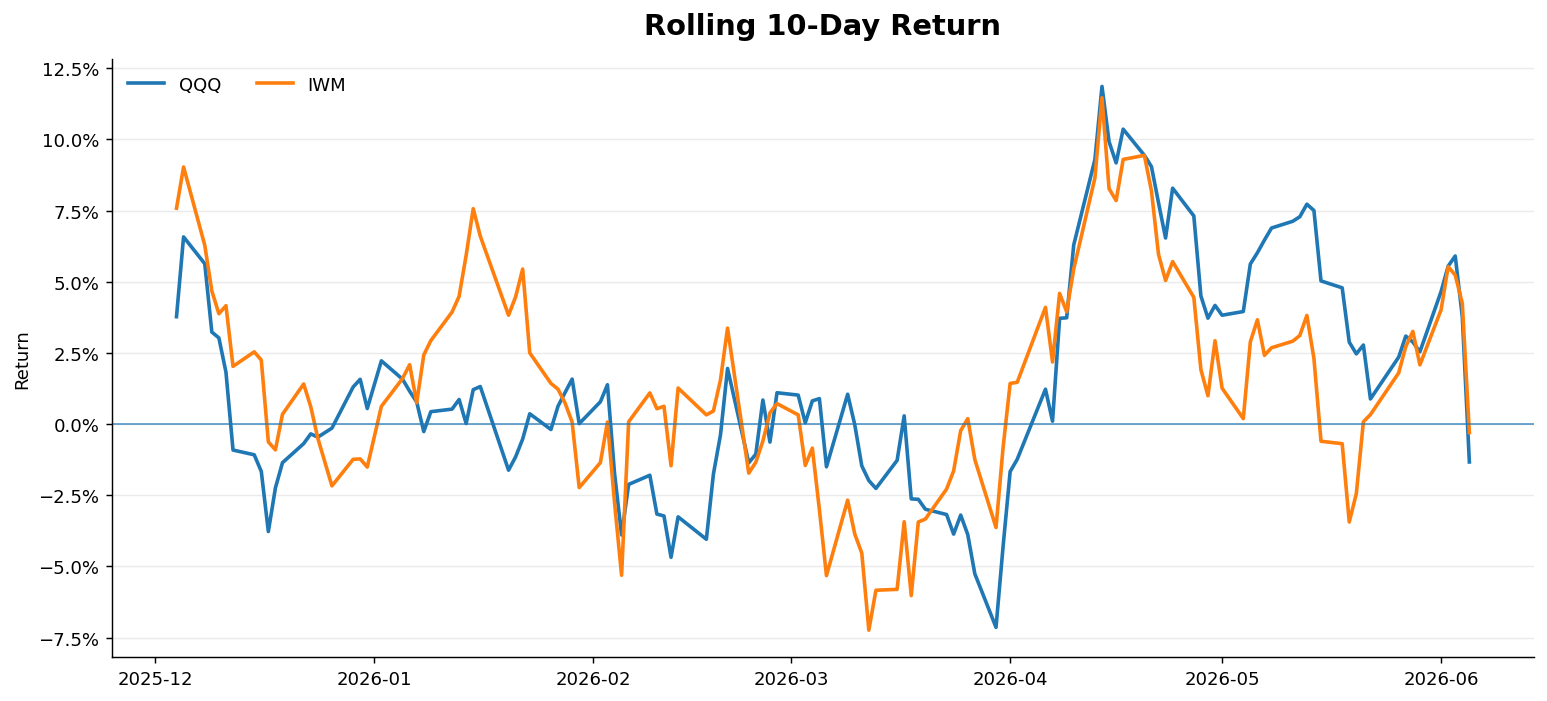

In [13]:
trend_plot(
    raw_return_wide.tail(126),
    title="Rolling 10-Day Return",
    ylabel="Return",
    symbols=['QQQ', 'IWM']
)

In [14]:
panel_view = get_asset_panel(
    raw_return_df,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
panel_view.loc['BRS'] = 0.5 * (panel_view.loc['RSP'] - panel_view.loc['SPY']) + 0.5 * (panel_view.loc['IWM'] - panel_view.loc['SPY'])
panel_view

,5-Day,10-Day,20-Day,60-Day,126-Day
symbol,,,,,
IWM,-0.030697,-0.002978,-0.002163,0.109650,0.125826
QQQ,-0.046081,-0.013314,0.014457,0.149886,0.125439
RSP,-0.004800,0.015126,0.020858,0.059984,0.090118
SPY,-0.025342,-0.006985,0.008127,0.089377,0.081212
BRS,0.007593,0.013059,0.001220,-0.004560,0.026760


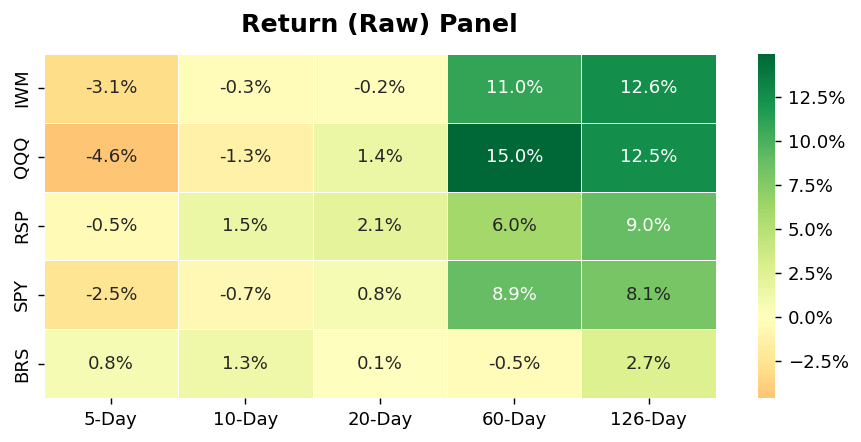

In [15]:
panel_plot(panel_view, title="Return (Raw) Panel")

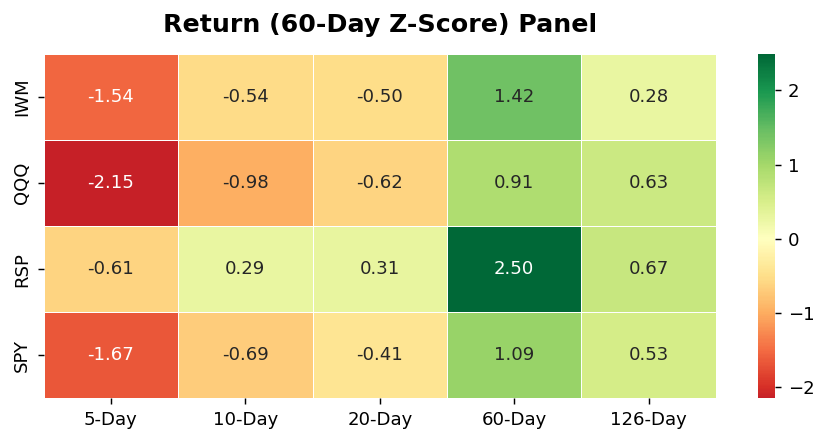

In [16]:
z_return_df = get_feature_df(df, return_features["zscore"])
panel_view = get_asset_panel(
    z_return_df,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['BRS'] = 0.5 * (panel_view.loc['RSP'] - panel_view.loc['SPY']) + 0.5 * (panel_view.loc['IWM'] - panel_view.loc['SPY'])
panel_plot(panel_view, title="Return (60-Day Z-Score) Panel", is_percentage=False)

## Metric 2 — Annualized Return

In [17]:
specs = []

specs += RETURN_FAMILY["ANNUALIZED_SIMPLE_RETURN"](
    price_col="adjClose",
    lookback=5,
)

specs += RETURN_FAMILY["ANNUALIZED_SIMPLE_RETURN"](
    price_col="adjClose",
    lookback=20,
)

specs += RETURN_FAMILY["ANNUALIZED_SIMPLE_RETURN"](
    price_col="adjClose",
    lookback=60,
)

specs += RETURN_FAMILY["ANNUALIZED_SIMPLE_RETURN"](
    price_col="adjClose",
    lookback=120,
)

m2_features = builder.build_published(specs)

In [18]:
feature_df = pd.DataFrame(m2_features, index=df.index)

m2_df = pd.concat(
    [df[["symbol", "date"]], feature_df,],
    axis=1,
)

m2_df

,symbol,date,px__ret__smplret__lb5__annual,px__ret__smplret__lb20__annual,px__ret__smplret__lb60__annual,px__ret__smplret__lb120__annual
0,IWM,2024-01-02,NaN,NaN,NaN,NaN
1,IWM,2024-01-03,NaN,NaN,NaN,NaN
2,IWM,2024-01-04,NaN,NaN,NaN,NaN
3,IWM,2024-01-05,NaN,NaN,NaN,NaN
4,IWM,2024-01-08,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2431,SPY,2026-06-01,1.373800,0.907224,0.587991,0.251013
2432,SPY,2026-06-02,0.821032,1.031936,0.688006,0.262541
2433,SPY,2026-06-03,0.288171,0.681331,0.579905,0.246279
2434,SPY,2026-06-04,0.180613,0.481685,0.615940,0.238850


# A2. Moving Average Distance Metrics

## Metric 3 — Distance from Moving Average

In [19]:
list(RAWPRICE_FAMILY.keys())

['MOVING_AVERAGE_PRICE',
 'MOVING_VOLATILITY_PRICE',
 'BOLLINGER_ZSCORE',
 'MOVING_AVERAGE_PRICE_DIFF',
 'MOVING_AVERAGE_PRICE_DIFF_TO_LONG_RATIO',
 'MOVING_AVERAGE_PRICE_DIFF_TO_ATR_RATIO',
 'MOVING_AVERAGE_PRICE_DIFF_TO_MVR_RATIO',
 'DISTANCE_FROM_MOVING_AVERAGE_PRICE',
 'DISTANCE_FROM_MOVING_AVERAGE_PRICE_VOLATILITY_NORMALIZED',
 'MOVING_AVERAGE_SLOPE',
 'MOVING_AVERAGE_PCT_SLOPE',
 'MOVING_AVERAGE_LOG_SLOPE_NORMALIZED_BY_RV']

In [20]:
dma_features = {}

family_name = RAWPRICE_FAMILY
template_name = "DISTANCE_FROM_MOVING_AVERAGE_PRICE"
price_cols = ["adjClose"]
windows = [5, 10, 20, 60, 126]

params_list = [
    {"price_col": p, "window": w}
    for p in price_cols for w in windows
]

dma_features["raw"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list
)

dma_features["zscore"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list,
    transform_fn=trsfm.add_ts_zscore,
    transform_params={"z_window": 60, "include_base": False}
)

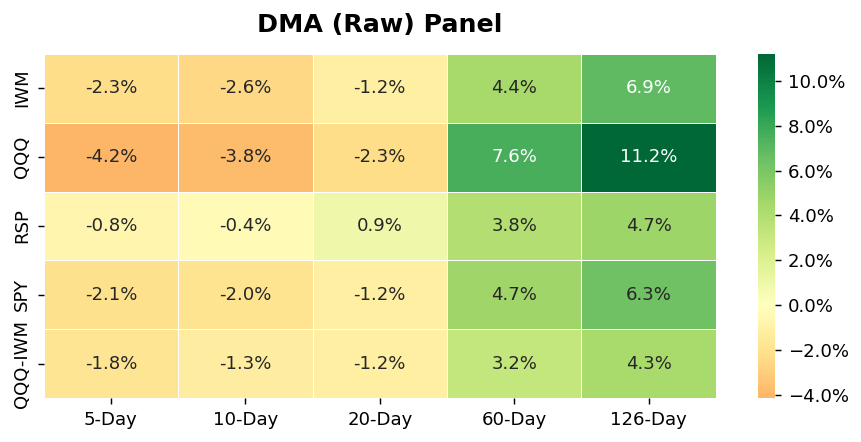

In [21]:
raw_dma_df = get_feature_df(df, dma_features["raw"])
panel_view = get_asset_panel(
    raw_dma_df,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="DMA (Raw) Panel", is_percentage=True)

In [22]:
raw_dma_df.tail()

,symbol,date,px__prc__dma__w5__raw,px__prc__dma__w10__raw,px__prc__dma__w20__raw,px__prc__dma__w60__raw,px__prc__dma__w126__raw
2431,SPY,2026-06-01,0.005842,0.015087,0.023353,0.084754,0.096935
2432,SPY,2026-06-02,0.004815,0.013628,0.021878,0.083927,0.097416
2433,SPY,2026-06-03,-0.003233,0.003768,0.012632,0.074333,0.088744
2434,SPY,2026-06-04,-0.000124,0.005441,0.014873,0.076303,0.091864
2435,SPY,2026-06-05,-0.021035,-0.019836,-0.011715,0.046960,0.062984


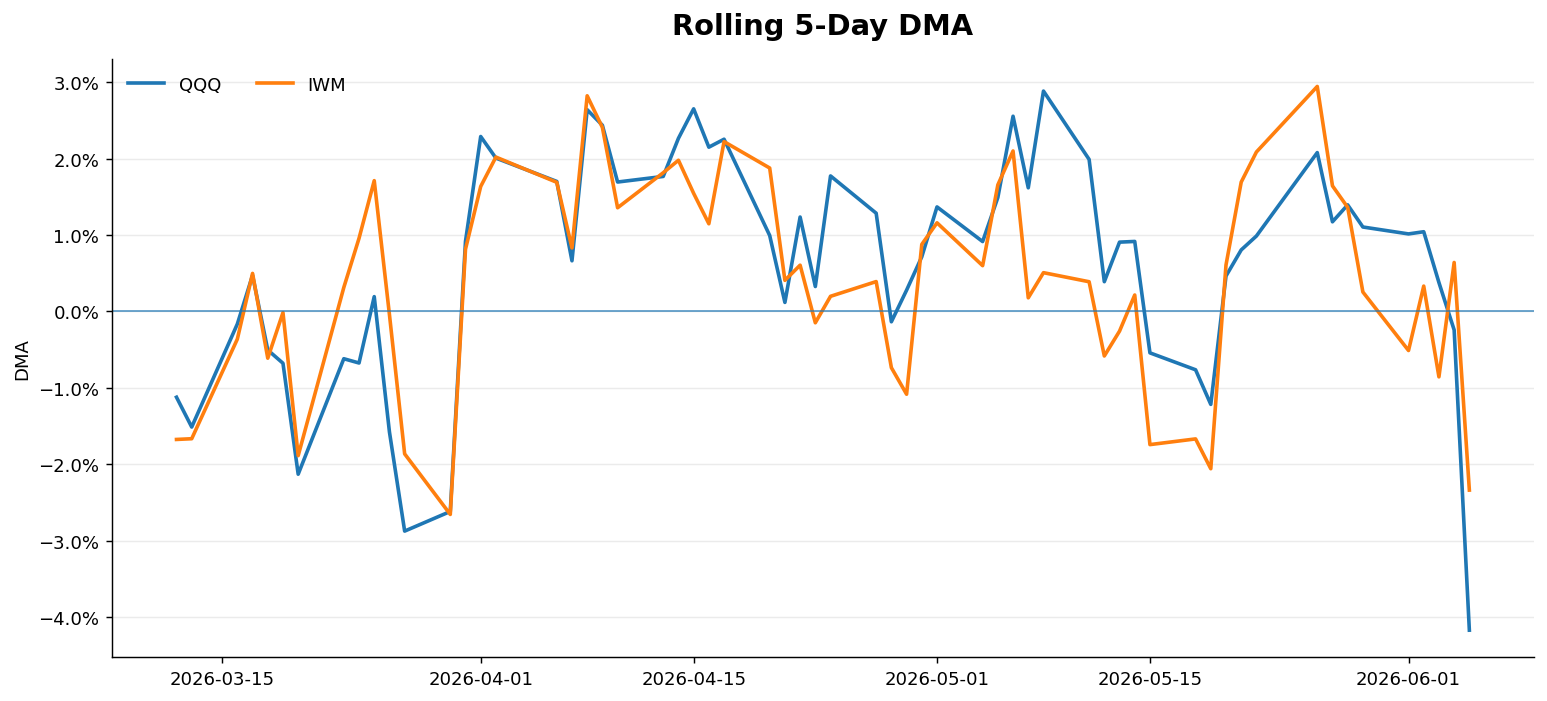

In [23]:
raw_dma_df = get_feature_df(df, dma_features["raw"])
raw_dma_wide = get_wide_view(raw_dma_df, "px__prc__dma__w5__raw")

trend_plot(
    raw_dma_wide.tail(60),
    title="Rolling 5-Day DMA",
    ylabel="DMA",
    symbols=['QQQ', 'IWM']
)

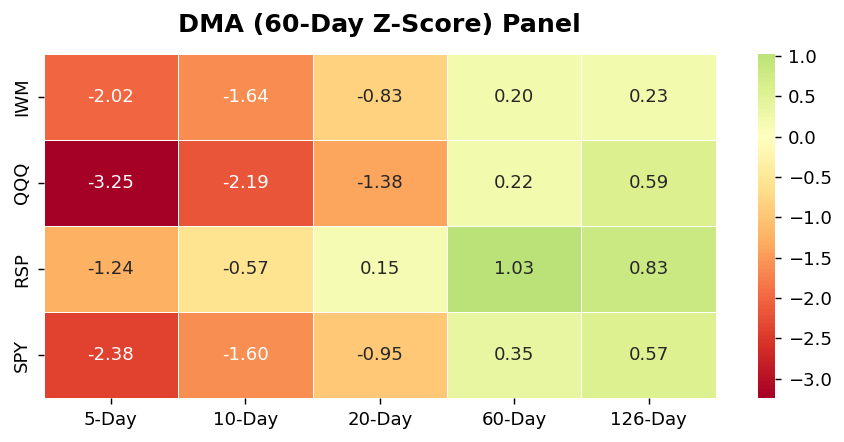

In [24]:
z_dma_df = get_feature_df(df, dma_features["zscore"])
panel_view = get_asset_panel(
    z_dma_df,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="DMA (60-Day Z-Score) Panel", is_percentage=False)

## Metric 4 — Volatility-adjusted MA distance

In [25]:
list(RAWPRICE_FAMILY.keys())

['MOVING_AVERAGE_PRICE',
 'MOVING_VOLATILITY_PRICE',
 'BOLLINGER_ZSCORE',
 'MOVING_AVERAGE_PRICE_DIFF',
 'MOVING_AVERAGE_PRICE_DIFF_TO_LONG_RATIO',
 'MOVING_AVERAGE_PRICE_DIFF_TO_ATR_RATIO',
 'MOVING_AVERAGE_PRICE_DIFF_TO_MVR_RATIO',
 'DISTANCE_FROM_MOVING_AVERAGE_PRICE',
 'DISTANCE_FROM_MOVING_AVERAGE_PRICE_VOLATILITY_NORMALIZED',
 'MOVING_AVERAGE_SLOPE',
 'MOVING_AVERAGE_PCT_SLOPE',
 'MOVING_AVERAGE_LOG_SLOPE_NORMALIZED_BY_RV']

In [26]:
vdma_features = {}

family_name = RAWPRICE_FAMILY
template_name = "DISTANCE_FROM_MOVING_AVERAGE_PRICE_VOLATILITY_NORMALIZED"
price_cols = ["adjClose"]
windows = [5, 10, 20, 60, 126]

params_list = [
    {"price_col": p, "window": w}
    for p in price_cols for w in windows
]

vdma_features["raw"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list
)

vdma_features["zscore"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list,
    transform_fn=trsfm.add_ts_zscore,
    transform_params={"z_window": 60, "include_base": False}
)

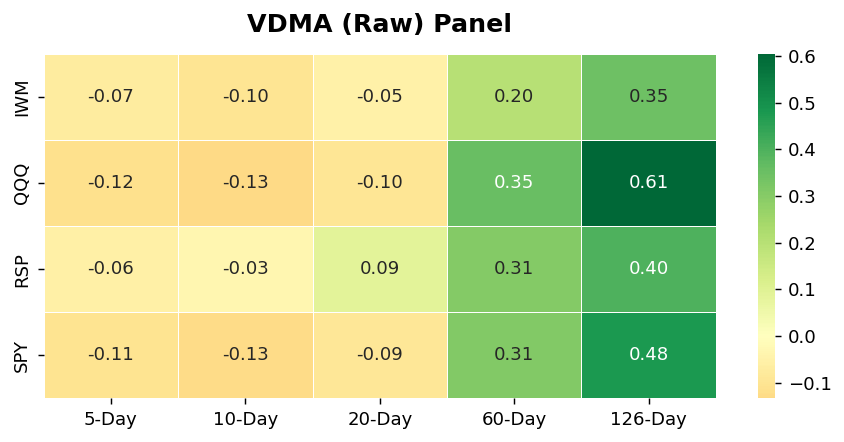

In [27]:
raw = get_feature_df(df, vdma_features["raw"])
panel_view = get_asset_panel(
    raw,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="VDMA (Raw) Panel", is_percentage=False)

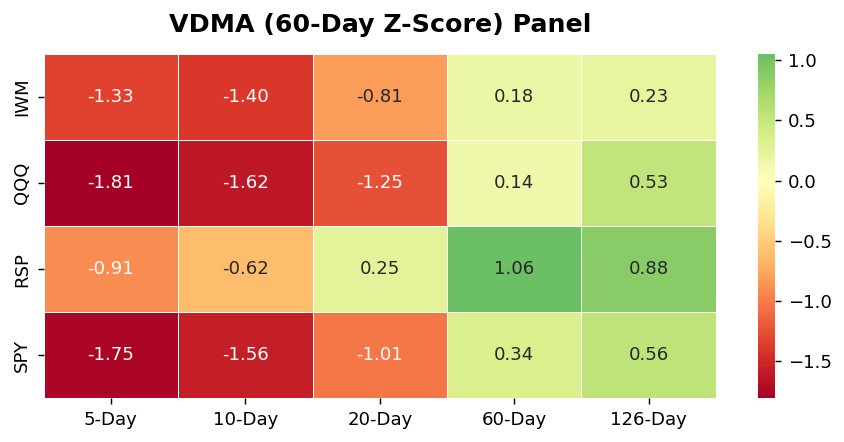

In [28]:
zscore = get_feature_df(df, vdma_features["zscore"])
panel_view = get_asset_panel(
    zscore,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="VDMA (60-Day Z-Score) Panel", is_percentage=False)

# A3. Trend Persistence Metrics

## Metric 5 — Moving Average Slope

In [29]:
list(TREND_FAMILY.keys())

['REGRESSION_TREND_LOG_PRICE',
 'REGRESSION_TREND_LOG_MA',
 'MOVING_AVERAGE_SLOPE',
 'MOVING_AVERAGE_PCT_SLOPE',
 'MOVING_AVERAGE_LOG_SLOPE_NORMALIZED_BY_RV']

In [30]:
mas_features = {}

family_name = TREND_FAMILY
template_name = "MOVING_AVERAGE_LOG_SLOPE_NORMALIZED_BY_RV"
price_cols = ["adjClose"]
ma_windows = [5, 10, 20, 60, 126]
windows = [10]

params_list = [
    {"price_col": p, "window": w, "ma_window": mw}
    for p in price_cols for mw in ma_windows for w in windows
]

mas_features["raw"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list
)

mas_features["zscore"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list,
    transform_fn=trsfm.add_ts_zscore,
    transform_params={"z_window": 60, "include_base": False}
)

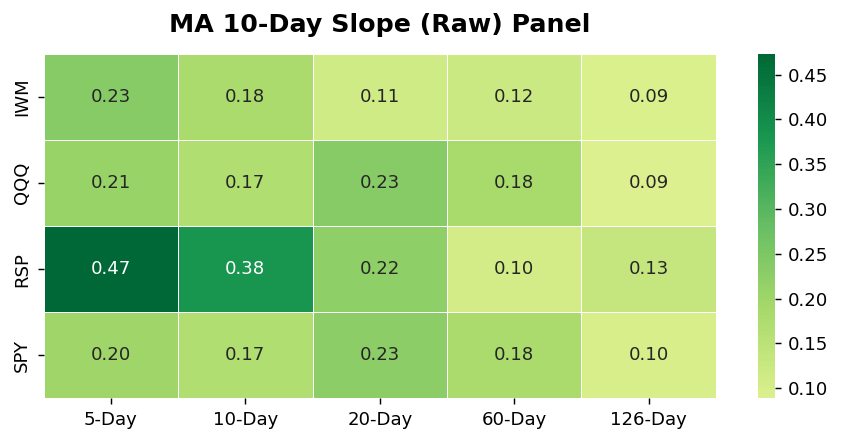

In [31]:
raw = get_feature_df(df, mas_features["raw"])
panel_view = get_asset_panel(
    raw,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="MA 10-Day Slope (Raw) Panel", is_percentage=False)

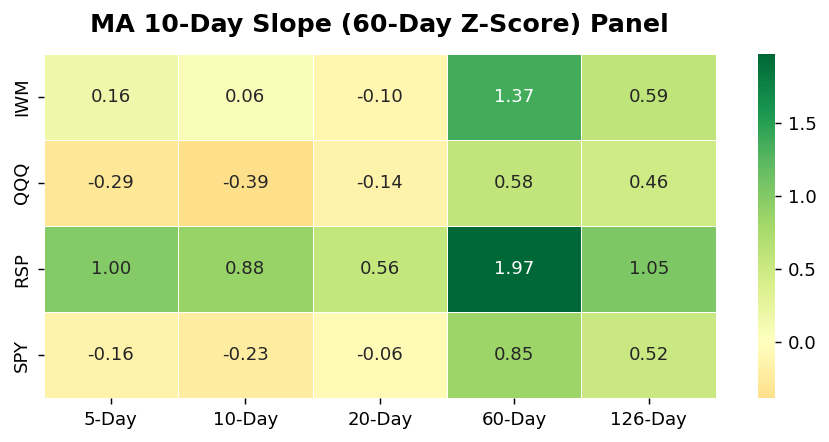

In [32]:
zscore = get_feature_df(df, mas_features["zscore"])
panel_view = get_asset_panel(
    zscore,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="MA 10-Day Slope (60-Day Z-Score) Panel", is_percentage=False)

## Metric 6 — Regression Slope

In [33]:
list(TREND_FAMILY.keys())

['REGRESSION_TREND_LOG_PRICE',
 'REGRESSION_TREND_LOG_MA',
 'MOVING_AVERAGE_SLOPE',
 'MOVING_AVERAGE_PCT_SLOPE',
 'MOVING_AVERAGE_LOG_SLOPE_NORMALIZED_BY_RV']

In [34]:
regtrd_features = {}

family_name = TREND_FAMILY
template_name = "REGRESSION_TREND_LOG_MA"
price_cols = ["adjClose"]
ma_windows = [5, 10, 20, 60, 126]
windows = [10]

params_list = [
    {"price_col": p, "window": w, "ma_window": mw}
    for p in price_cols for mw in ma_windows for w in windows
]

regtrd_features["raw"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list
)

regtrd_features["zscore"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list,
    transform_fn=trsfm.add_ts_zscore,
    transform_params={"z_window": 60, "include_base": False, "target":{"signal": "regbeta-rv"}}
)

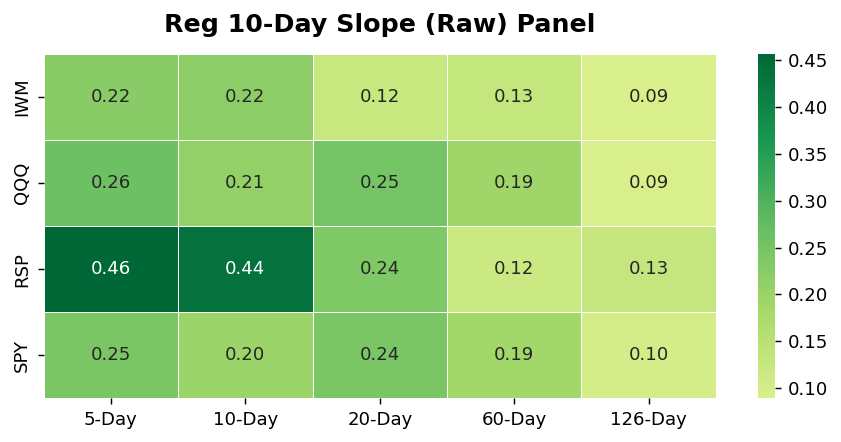

In [35]:
raw = get_feature_df(df, regtrd_features["raw"])
panel_view = get_asset_panel(
    raw[['symbol', 'date'] + [x for x in raw.columns if 'regbeta-rv' in x]],
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="Reg 10-Day Slope (Raw) Panel", is_percentage=False)

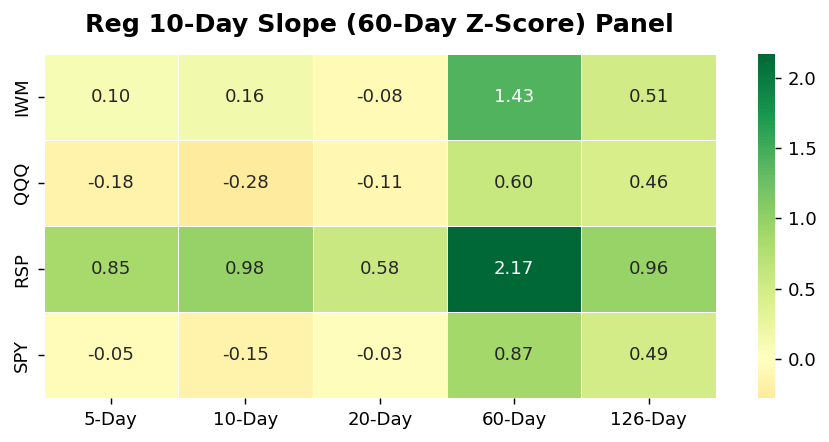

In [36]:
zscore = get_feature_df(df, regtrd_features["zscore"])
panel_view = get_asset_panel(
    zscore,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="Reg 10-Day Slope (60-Day Z-Score) Panel", is_percentage=False)

# A4. Volatility Metrics

## Metric 7 — Realized Volatility

In [37]:
list(RETURN_FAMILY.keys())

['RETURN',
 'ANNUALIZED_SIMPLE_RETURN',
 'MOVING_AVERAGE_RETURN',
 'MOVING_VOLATILITY_RETURN',
 'RETURN_ZSCORE',
 'RETURN_RATIO',
 'REALIZED_VOLATILITY']

In [38]:
rv_features = {}

family_name = RETURN_FAMILY
template_name = "REALIZED_VOLATILITY"
price_cols = ["adjClose"]
windows = [5, 10, 20, 60, 126]

params_list = [
    {"price_col": p, "window": w}
    for p in price_cols for w in windows
]

rv_features["raw"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list
)

rv_features["zscore"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list,
    transform_fn=trsfm.add_ts_zscore,
    transform_params={"z_window": 60, "include_base": False}
)

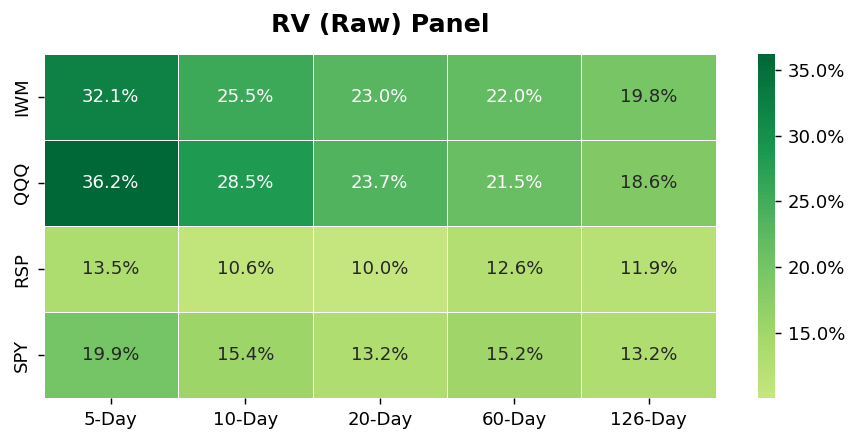

In [39]:
raw = get_feature_df(df, rv_features["raw"])
panel_view = get_asset_panel(
    raw,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="RV (Raw) Panel", is_percentage=True)

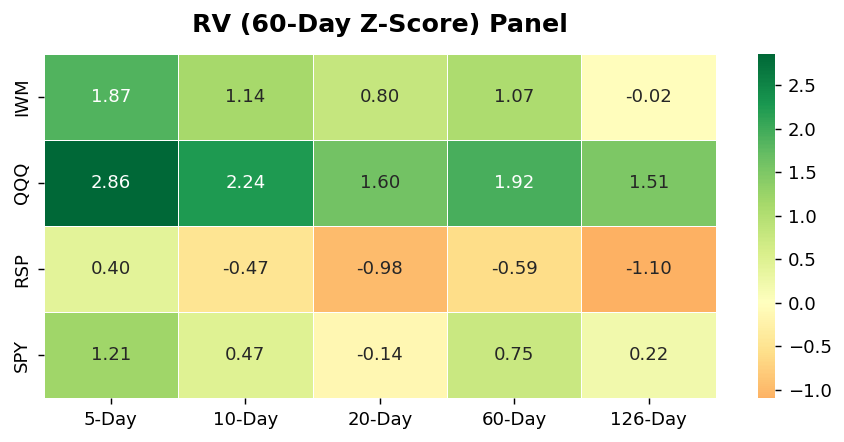

In [40]:
zscore = get_feature_df(df, rv_features["zscore"])
panel_view = get_asset_panel(
    zscore,
    column_names=['5-Day', '10-Day', '20-Day', '60-Day', '126-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="RV (60-Day Z-Score) Panel", is_percentage=False)

# A5. Drawdown Metrics

## Metric 8 — Rolling Drawdown

In [41]:
list(MDD_FAMILY.keys())

['MDD', 'MDD_ATR_NORM']

In [42]:
mdd_features = {}

family_name = MDD_FAMILY
template_name = "MDD"
price_cols = ["adjClose"]
windows = [20, 60, 126, 252]

params_list = [
    {"price_col": p, "window": w,}
    for p in price_cols for w in windows
]

mdd_features["raw"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list
)

mdd_features["zscore"] = get_features(
    builder=builder,
    family=family_name,
    template=template_name,
    params_lst=params_list,
    transform_fn=trsfm.add_ts_zscore,
    transform_params={"z_window": 60, "include_base": False}
)

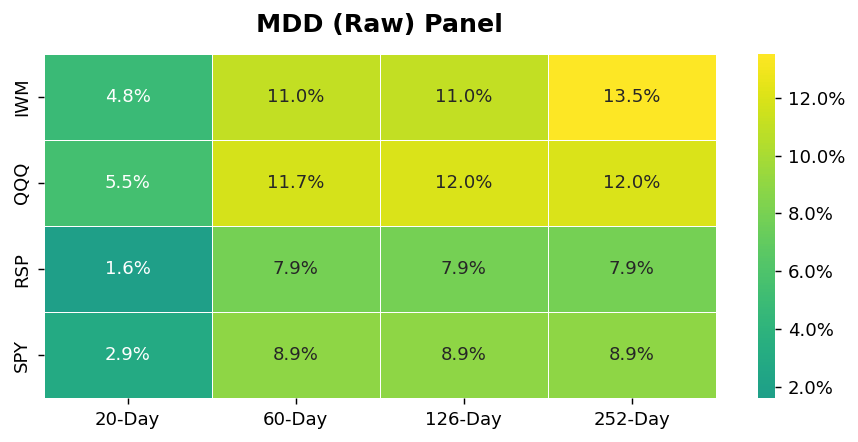

In [43]:
raw = get_feature_df(df, mdd_features["raw"])
panel_view = get_asset_panel(
    raw,
    column_names=['20-Day', '60-Day', '126-Day', '252-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="MDD (Raw) Panel", is_percentage=True, cmap="viridis")

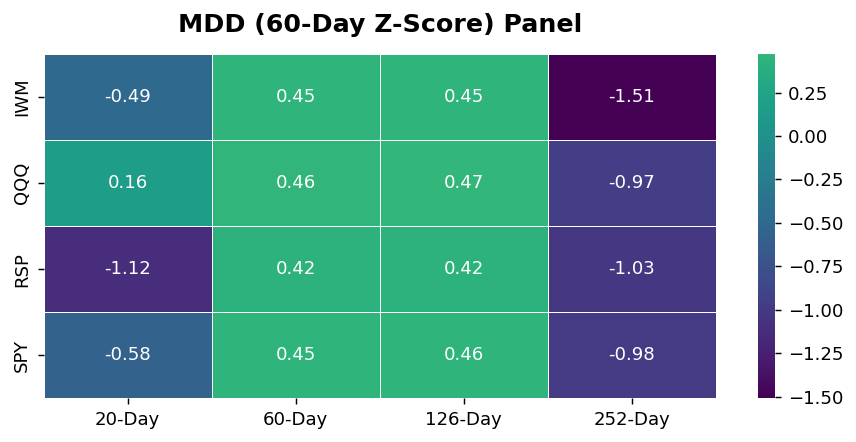

In [44]:
zscore = get_feature_df(df, mdd_features["zscore"])
panel_view = get_asset_panel(
    zscore,
    column_names=['20-Day', '60-Day', '126-Day', '252-Day']
)
# panel_view.loc['QQQ-IWM'] = panel_view.loc['QQQ'] - panel_view.loc['IWM']
panel_plot(panel_view, title="MDD (60-Day Z-Score) Panel", is_percentage=False, cmap="viridis")